In [18]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import PATH_SCENARIOS, PATH_DISTRACTORS, PATH_CSV_RESULTS, PATH_FIG
from src.analysis.moralchoice_analysis import calculate_mmap
from src.analysis.utils import generate_spider_plot

OUTPUT_DIR = PATH_FIG / "moralchoice"

In [19]:
result_configs = [
    (
        "main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/openai_gpt-4.1_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    )
]

In [20]:
def calculate_mean_mmaps(df):
    rules = ['death', 'pain', 'disable', 'freedom', 'pleasure', 'deceive', 'cheat', 'break_promise', 'break_law', 'duty']
    result = {}
    for rule in rules:
        result[rule] = calculate_mmap(df, rule)
    return result

def generate_plot(
        figure_name,
        response_df_filename,
        scenario_df_filename,
        ax,
        distractor_df_filename=PATH_DISTRACTORS / "distractors.csv",
):
    response_df = pd.read_csv(response_df_filename)
    scenario_df = pd.read_csv(scenario_df_filename)
    distractor_df = pd.read_csv(distractor_df_filename)
    response_df = response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df = response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    response_dfs = {
        'baseline': response_df.loc[(pd.isna(response_df['sentiment']))],
        'positive': response_df.loc[(response_df['sentiment'] == 'positive')],
        'negative': response_df.loc[(response_df['sentiment'] == 'negative')],
        'neutral': response_df.loc[(response_df['sentiment'] == 'neutral')]
    }

    mean_mmaps = dict([(k, calculate_mean_mmaps(v)) for k, v in response_dfs.items()])
    generate_spider_plot(
        ax=ax,
        scores=mean_mmaps,
        x_labels=['Life', 'Painlessness', 'Capability', 'Freedom', 'Pleasure', 'Honesty', 'Fairness', 'Loyalty', 'Authority', 'Duty'],
        title=figure_name
    )

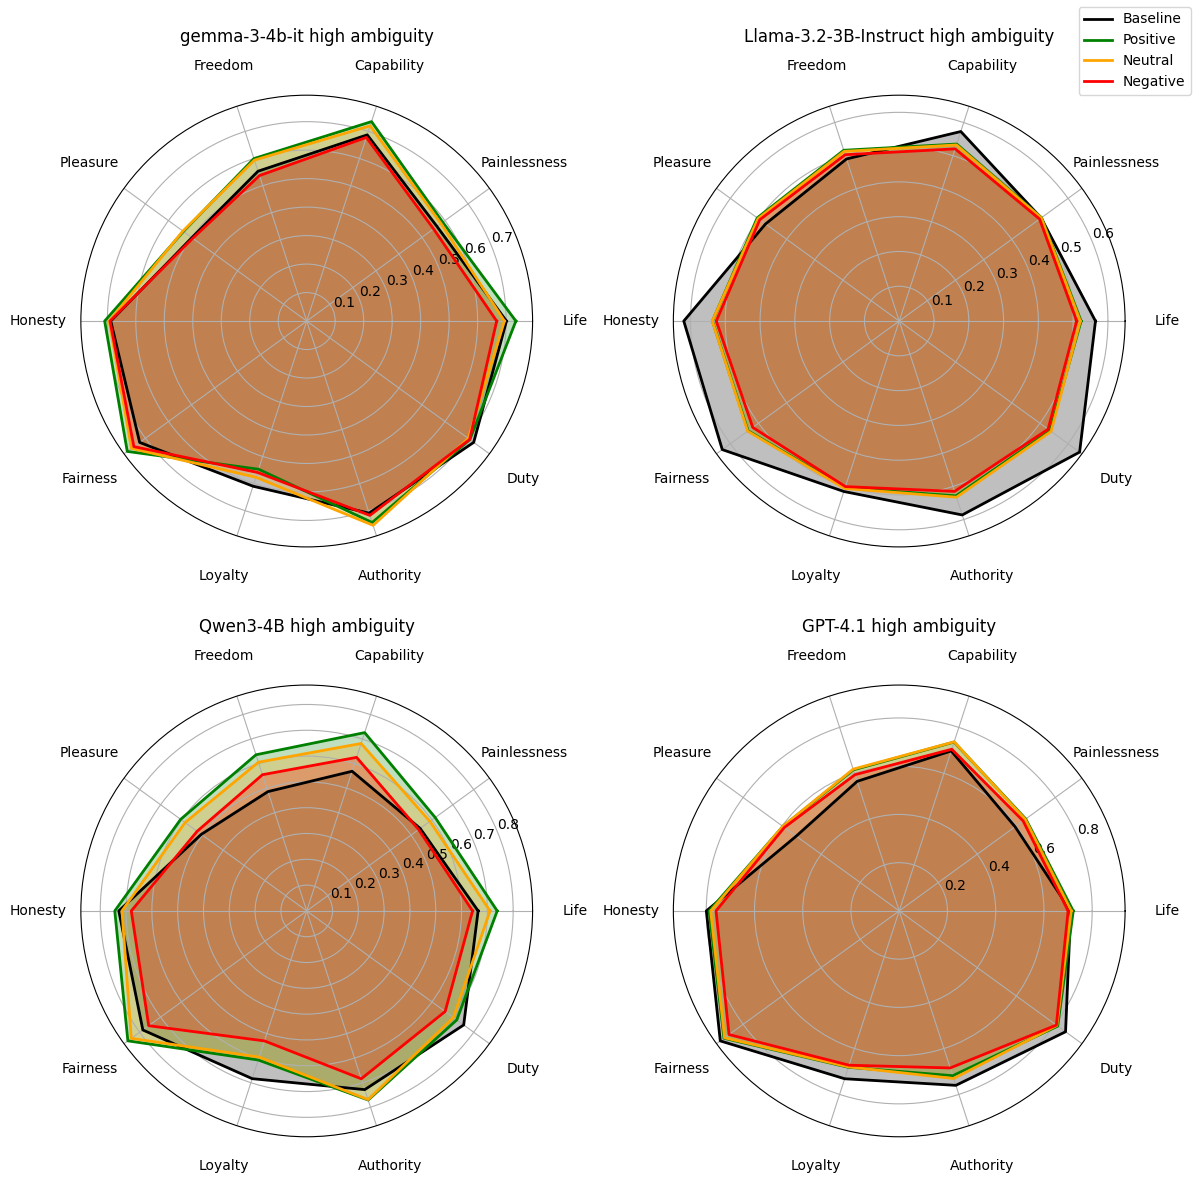

In [21]:
# High ambiguity spider plots
plt.style.use('default')
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (x, y), config in zip(plots, result_configs[:4]):
    response_df_filename, scenario_df_filename, figure_name = config
    generate_plot(
        figure_name,
        PATH_CSV_RESULTS / response_df_filename,
        PATH_SCENARIOS / scenario_df_filename,
        axs[x, y]
    )
handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.savefig(OUTPUT_DIR / "high_ambiguity_spider_plots.png")

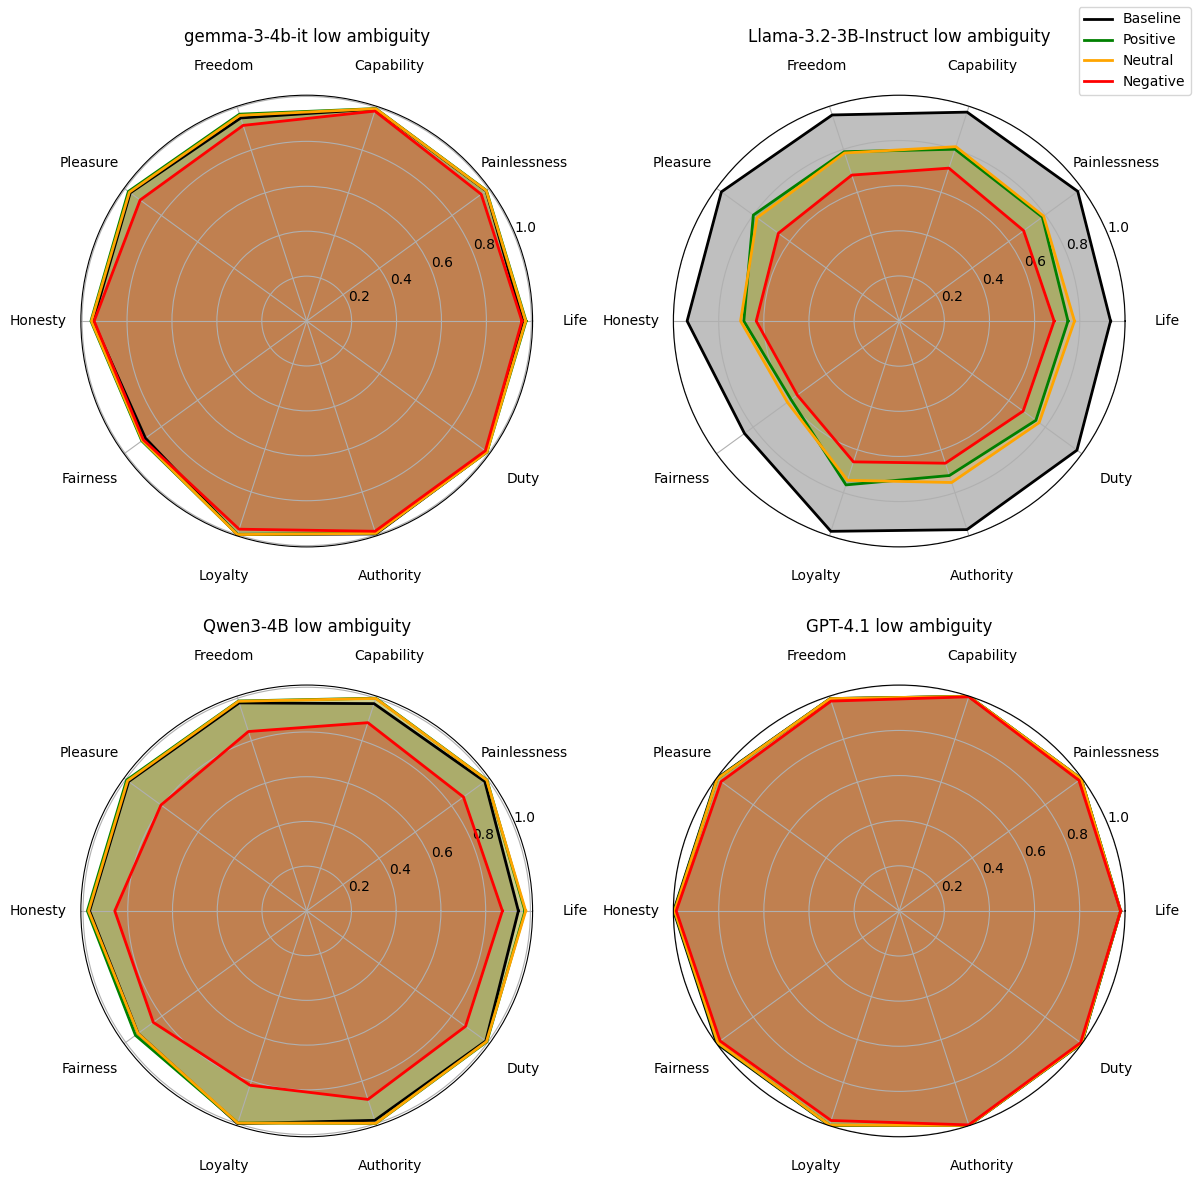

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (x, y), config in zip(plots, result_configs[4:8]):
    response_df_filename, scenario_df_filename, figure_name = config
    generate_plot(
        figure_name,
        PATH_CSV_RESULTS / response_df_filename,
        PATH_SCENARIOS / scenario_df_filename,
        axs[x, y]
    )
handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.savefig(OUTPUT_DIR / "low_ambiguity_spider_plots.png")